# Tumor Cluster Marker Gene Discovery

This notebook identifies mitotic genes that distinguish tumor subgroups discovered in the tumor–fetal transcriptomics analysis.

Each cluster is compared against all other tumors to find marker genes associated with different developmental-like expression programs.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

cwd = Path.cwd()

if (cwd / "data").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "data").exists():
    REPO_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find repo root containing 'data/'")

DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

tumor_path = DATA_DIR / "tcga" / "primary_tumor_only_mitotic_tpm.csv"
cluster_path = TABLES_DIR / "tumor_cluster_matches.csv"

print(tumor_path.exists(), cluster_path.exists())

True True


## Load Tumor Expression Data and Cluster Assignments

In [2]:
tumor_df = pd.read_csv(tumor_path, index_col=0)
cluster_df = pd.read_csv(cluster_path)

print("Tumor matrix shape:", tumor_df.shape)
print("Cluster table shape:", cluster_df.shape)
cluster_df.head()

Tumor matrix shape: (560, 9185)
Cluster table shape: (500, 6)


,tumor_sample,closest_fetal_profile,distance,stage,tissue,cluster
0,TCGA-FD-A5BV-01,7 week post conception | kidney,0.666397,7 week post conception,kidney,0
1,TCGA-DX-A8BM-01,5 week post conception | forebrain,0.759351,5 week post conception,forebrain,2
2,TCGA-DE-A3KN-01,infant | testis,0.442527,infant,testis,1
3,TCGA-EJ-5519-01,11 week post conception | hindbrain,0.574606,11 week post conception,hindbrain,1
4,TCGA-BP-4160-01,16 week post conception | heart,0.524920,16 week post conception,heart,1


In [3]:
shared_samples = [s for s in cluster_df["tumor_sample"] if s in tumor_df.columns]

print("Shared samples:", len(shared_samples))
print("Unique clusters:", sorted(cluster_df["cluster"].unique()))

Shared samples: 500
Unique clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Align Tumor Expression Matrix to Clustered Samples

The cluster analysis was performed on a 500-sample tumor subset.  
Here we restrict the tumor expression matrix to those same samples so that each column has a cluster label.

In [4]:
# Keep only clustered samples, in the same order as cluster_df
clustered_samples = cluster_df["tumor_sample"].tolist()
tumor_subset = tumor_df[clustered_samples].copy()

print("Tumor subset shape:", tumor_subset.shape)
print("First 5 columns:", tumor_subset.columns[:5].tolist())

Tumor subset shape: (560, 500)
First 5 columns: ['TCGA-FD-A5BV-01', 'TCGA-DX-A8BM-01', 'TCGA-DE-A3KN-01', 'TCGA-EJ-5519-01', 'TCGA-BP-4160-01']


In [5]:
# Build sample -> cluster mapping
sample_to_cluster = dict(zip(cluster_df["tumor_sample"], cluster_df["cluster"]))

# Confirm all tumor subset columns have a cluster label
missing_labels = [s for s in tumor_subset.columns if s not in sample_to_cluster]
print("Missing labels:", len(missing_labels))

cluster_labels = pd.Series(
    [sample_to_cluster[s] for s in tumor_subset.columns],
    index=tumor_subset.columns,
    name="cluster"
)

print(cluster_labels.value_counts().sort_index())

Missing labels: 0
cluster
0    138
1    152
2    165
3     45
Name: count, dtype: int64


## Identify Marker Genes for Each Tumor Cluster

For each cluster, we compare tumors in that cluster against all other tumors using Welch’s t-test.

This gives a first-pass list of genes that are unusually high or low in each tumor subgroup.

In [6]:
from scipy.stats import ttest_ind
import numpy as np

marker_results = {}

# Expression matrix as samples x genes
expr = tumor_subset.T.copy()

for cluster in sorted(cluster_labels.unique()):
    in_cluster = expr.loc[cluster_labels[cluster_labels == cluster].index]
    out_cluster = expr.loc[cluster_labels[cluster_labels != cluster].index]

    tstats, pvals = ttest_ind(
        in_cluster,
        out_cluster,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    mean_in = in_cluster.mean(axis=0)
    mean_out = out_cluster.mean(axis=0)
    mean_diff = mean_in - mean_out

    result_df = pd.DataFrame({
        "gene": expr.columns,
        "mean_in_cluster": mean_in.values,
        "mean_out_cluster": mean_out.values,
        "mean_difference": mean_diff.values,
        "t_stat": tstats,
        "p_value": pvals
    })

    result_df = result_df.sort_values(["p_value", "mean_difference"], ascending=[True, False])
    marker_results[cluster] = result_df

    print(f"Cluster {cluster}: {in_cluster.shape[0]} in-cluster vs {out_cluster.shape[0]} out-of-cluster")

Cluster 0: 138 in-cluster vs 362 out-of-cluster
Cluster 1: 152 in-cluster vs 348 out-of-cluster
Cluster 2: 165 in-cluster vs 335 out-of-cluster
Cluster 3: 45 in-cluster vs 455 out-of-cluster


In [7]:
# Preview top markers
for cluster, df in marker_results.items():
    print(f"\nCluster {cluster} top 10 marker genes:")
    display(df.head(10))


Cluster 0 top 10 marker genes:


,gene,mean_in_cluster,mean_out_cluster,mean_difference,t_stat,p_value
203,ENSG00000117399,5.673525,3.627804,2.045721,13.868244,5.384871e-37
501,ENSG00000175063,6.562433,4.475068,2.087365,13.706334,1.838071e-36
518,ENSG00000178999,4.743071,2.844171,1.898900,13.009996,2.300760e-33
106,ENSG00000100526,4.666903,3.184741,1.482162,12.101276,1.760535e-29
109,ENSG00000101057,4.909283,2.758580,2.150703,12.075428,1.786401e-29
407,ENSG00000157456,4.594683,3.001311,1.593372,11.950008,4.092790e-29
84,ENSG00000089685,4.597453,2.896875,1.700578,11.858542,1.000314e-28
194,ENSG00000115163,3.380584,1.649921,1.730663,11.727762,3.666873e-28
459,ENSG00000166851,4.426496,2.902596,1.523900,11.319827,1.397919e-26
90,ENSG00000093009,3.539901,1.933122,1.606779,11.417202,1.540812e-26



Cluster 1 top 10 marker genes:


,gene,mean_in_cluster,mean_out_cluster,mean_difference,t_stat,p_value
203,ENSG00000117399,1.760837,5.254495,-3.493658,-27.789095,4.604509e-95
340,ENSG00000142945,0.457013,3.562186,-3.105173,-27.009371,4.776693e-95
358,ENSG00000145386,0.731412,3.468381,-2.736970,-25.967512,1.052670e-91
284,ENSG00000134690,0.577368,3.467145,-2.889778,-25.730744,8.912200e-90
279,ENSG00000134057,3.159162,5.566134,-2.406972,-25.782074,1.153862e-89
459,ENSG00000166851,1.182646,4.258144,-3.075498,-25.787630,3.522732e-87
82,ENSG00000088325,1.465851,4.672052,-3.206201,-25.742688,4.730177e-85
194,ENSG00000115163,-0.221371,3.153565,-3.374936,-25.748410,5.724169e-85
109,ENSG00000101057,0.542759,4.579274,-4.036515,-25.854935,8.770873e-85
81,ENSG00000087586,1.295893,3.892959,-2.597066,-25.228742,1.236412e-84



Cluster 2 top 10 marker genes:


,gene,mean_in_cluster,mean_out_cluster,mean_difference,t_stat,p_value
89,ENSG00000092853,2.332495,-0.467629,2.800124,22.610867,2.080365e-78
421,ENSG00000161800,5.016463,3.133045,1.883418,22.088367,9.654662e-76
365,ENSG00000146918,4.071185,2.354261,1.716924,22.173388,2.540185e-75
376,ENSG00000149503,4.322425,2.632510,1.689915,22.033776,4.879902e-75
504,ENSG00000175305,2.816748,0.429983,2.386766,22.271897,2.144749e-73
131,ENSG00000104738,6.193690,4.228827,1.964863,21.550569,6.898086e-73
53,ENSG00000072501,5.167157,3.499650,1.667507,21.762247,3.901409e-72
312,ENSG00000138160,3.734512,1.488674,2.245838,21.188036,3.038970e-71
299,ENSG00000136824,3.697239,2.016313,1.680925,21.529631,4.236226e-71
15,ENSG00000012048,3.315607,1.456582,1.859026,21.448353,6.141526e-71



Cluster 3 top 10 marker genes:


,gene,mean_in_cluster,mean_out_cluster,mean_difference,t_stat,p_value
419,ENSG00000160551,1.407692,3.074876,-1.667184,-14.061315,1.896448e-20
227,ENSG00000121774,4.999779,6.304756,-1.304977,-14.402784,1.750043e-19
124,ENSG00000103275,5.266417,6.539564,-1.273148,-14.025325,3.058968e-19
117,ENSG00000101868,0.504108,2.335075,-1.830967,-13.784466,3.111070e-19
9,ENSG00000010244,4.964004,6.288832,-1.324828,-13.922075,4.681288e-19
270,ENSG00000131558,3.468837,4.645049,-1.176212,-13.562094,5.523122e-19
88,ENSG00000090989,2.371970,3.955594,-1.583624,-13.953449,5.869707e-19
259,ENSG00000128989,3.776187,5.334574,-1.558387,-13.326803,6.925108e-19
45,ENSG00000068796,1.072079,3.418833,-2.346754,-13.434854,1.224334e-18
502,ENSG00000175203,5.769113,6.896345,-1.127232,-13.275232,1.281508e-18


In [8]:
# Save top 20 marker genes per cluster
for cluster, df in marker_results.items():
    out_path = TABLES_DIR / f"cluster_{cluster}_marker_genes.csv"
    df.head(20).to_csv(out_path, index=False)

print("Saved marker gene tables.")

Saved marker gene tables.


In [9]:
# Collect top genes per cluster
top_genes = []

for cluster, df in marker_results.items():
    genes = df.head(10)["gene"].tolist()
    top_genes.extend(genes)

# Remove duplicates
top_genes = list(set(top_genes))

print("Total unique marker genes:", len(top_genes))

Total unique marker genes: 36


In [10]:
# Subset expression to top genes
heatmap_data = tumor_subset.loc[top_genes].copy()

# Add cluster labels for ordering
cluster_order = cluster_labels.loc[heatmap_data.columns]

# Sort columns by cluster
sorted_samples = cluster_order.sort_values().index
heatmap_data = heatmap_data[sorted_samples]

print(heatmap_data.shape)

(36, 500)


In [11]:
from sklearn.preprocessing import StandardScaler

# Normalize across samples
heatmap_scaled = pd.DataFrame(
    StandardScaler().fit_transform(heatmap_data.T).T,
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

In [14]:
cluster_means = {}

for cluster in sorted(cluster_labels.unique()):
    samples = cluster_labels[cluster_labels == cluster].index
    cluster_means[cluster] = tumor_subset[samples].mean(axis=1)

cluster_mean_df = pd.DataFrame(cluster_means)

print(cluster_mean_df.shape)
cluster_mean_df.head()

(560, 4)


,0,1,2,3
sample,,,,
ENSG00000000460,2.517854,1.190357,3.105230,0.749040
ENSG00000002822,4.809379,4.359145,4.356191,4.484947
ENSG00000004142,5.966836,6.011330,6.404937,5.640416
ENSG00000004897,4.030030,4.155815,4.867610,2.848238
ENSG00000006611,-1.442997,0.944030,-1.587318,-1.274082


In [15]:
cluster_mean_df = cluster_mean_df.loc[top_genes]

In [16]:
from sklearn.preprocessing import StandardScaler

cluster_mean_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_mean_df.T).T,
    index=cluster_mean_df.index,
    columns=cluster_mean_df.columns
)

In [18]:
cluster_order = cluster_mean_scaled.mean(axis=0).sort_values(ascending=False).index
cluster_mean_scaled = cluster_mean_scaled[cluster_order]

In [ ]:
top_genes_small = top_genes[:20]
cluster_mean_scaled_small = cluster_mean_scaled.loc[top_genes_small]

## Top Marker Genes by Tumor Cluster

To make the cluster differences easier to interpret, we summarize the strongest positive marker genes for each tumor cluster.

In [23]:
top_markers_summary = []

for cluster, df in marker_results.items():
    top_df = df.sort_values("mean_difference", ascending=False).head(5).copy()
    top_df["cluster"] = cluster
    top_markers_summary.append(top_df)

top_markers_summary = pd.concat(top_markers_summary, ignore_index=True)
top_markers_summary.head()

,gene,mean_in_cluster,mean_out_cluster,mean_difference,t_stat,p_value,cluster
0,ENSG00000101057,4.909283,2.758580,2.150703,12.075428,1.786401e-29,0
1,ENSG00000175063,6.562433,4.475068,2.087365,13.706334,1.838071e-36,0
2,ENSG00000117399,5.673525,3.627804,2.045721,13.868244,5.384871e-37,0
3,ENSG00000178999,4.743071,2.844171,1.898900,13.009996,2.300760e-33,0
4,ENSG00000115163,3.380584,1.649921,1.730663,11.727762,3.666873e-28,0


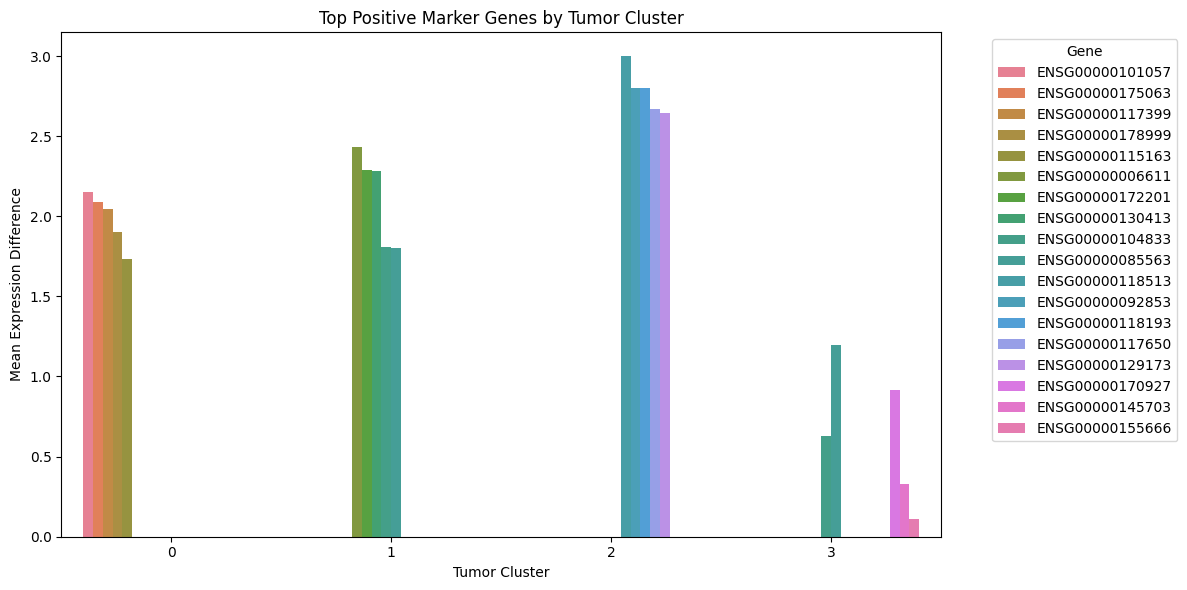

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_markers_summary,
    x="cluster",
    y="mean_difference",
    hue="gene"
)

plt.title("Top Positive Marker Genes by Tumor Cluster")
plt.xlabel("Tumor Cluster")
plt.ylabel("Mean Expression Difference")
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_marker_genes_by_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

## Interpretation (Marker Genes by Cluster)

This figure shows the strongest genes that define each tumor group.

Each cluster has its own set of genes that are expressed more strongly than in the other tumors. In other words, these genes act like “signatures” that distinguish one group of tumors from another.

A few key patterns emerge:

- Some clusters show consistently higher expression of many mitotic genes, indicating a more active cell division program.
- Other clusters show much lower expression of those same genes, suggesting a less active or more regulated state.
- One cluster stands out with the strongest overall gene activation, while another shows weaker or more selective activation.

In simple terms:

> Tumors are not all behaving the same way.  
> They fall into different groups, and each group uses a different version of the cell division machinery.

This supports the idea that cancer is not a single uniform process, but a collection of distinct biological states, even when focusing on the same set of genes.